## Importing the libraries

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import sklearn
from sklearn import model_selection as ms
from sklearn import preprocessing as pp
from sklearn import metrics as met 
from sklearn import cluster as cls
from mpl_toolkits.mplot3d import Axes3D

## Load and Prepare Data

In [2]:
basedf = pd.read_csv('Mall_Customers.csv')
basedf

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [3]:
df = basedf.copy()
df.info 

<bound method DataFrame.info of      CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0             1    Male   19                  15                      39
1             2    Male   21                  15                      81
2             3  Female   20                  16                       6
3             4  Female   23                  16                      77
4             5  Female   31                  17                      40
..          ...     ...  ...                 ...                     ...
195         196  Female   35                 120                      79
196         197  Female   45                 126                      28
197         198    Male   32                 126                      74
198         199    Male   32                 137                      18
199         200    Male   30                 137                      83

[200 rows x 5 columns]>

Costumer ID is not required so it will be removed and gender needs to be replaced with 0/1

In [4]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

No nan nothing to worry about

<Figure size 3000x600 with 0 Axes>

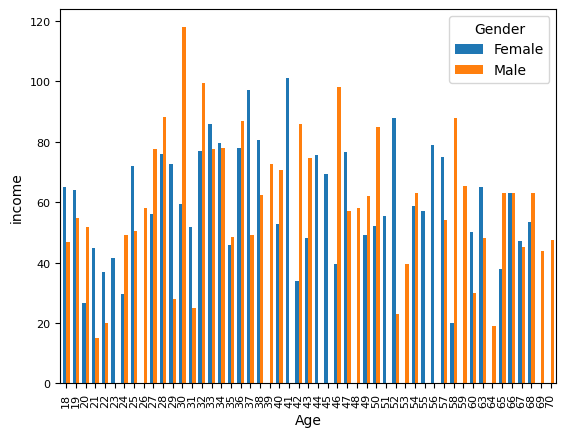

In [5]:
age_spend_income = df.groupby([ df['Age'],df['Gender']])['Annual Income (k$)'].mean().unstack()
plt.figure(figsize=(30, 6))
age_spend_income.plot(kind = 'bar', fontsize = 8 , width=0.70)
plt.subplots_adjust(bottom=0.1)
plt.xlabel('Age')
plt.ylabel('income')
plt.show()

In [6]:
df['Gender'] = df['Gender'].replace({ 'Male' :  1 ,
                  'Female' : 0
                })
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')

In [7]:
df['Gender'] = df['Gender'].astype(int)
df.dtypes

CustomerID                int64
Gender                    int64
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

In [8]:
df = df.drop(columns = 'CustomerID')
df.columns

Index(['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='str')

## Visualization Before Clustering

<Axes: xlabel='Age'>

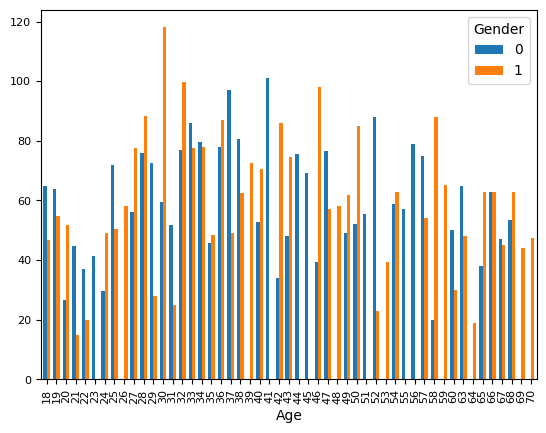

In [9]:
gen_age_income = df.groupby( [df['Age'],df['Gender']])['Annual Income (k$)'].mean().sort_values(ascending=False).unstack()
gen_age_income.plot(kind = 'bar', fontsize = 8, width=0.70) # bar plots looks like a random data didnt help much just that man have more avrage income

<Axes: xlabel='Age'>

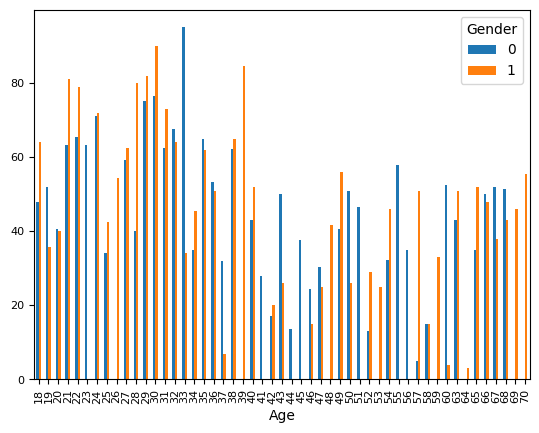

In [10]:
gen_age_income = df.groupby( [df['Age'],df['Gender']])['Spending Score (1-100)'].mean().sort_values(ascending=False).unstack()
gen_age_income.plot(kind = 'bar', fontsize = 8) # this one helped we can see that people age over 40 has lower Spending Score

I dont know if the Gender would be a helpfull feature but we'll keep it we can drop it later

## Finding The Elbow For KMeans

In [11]:
wcss = []
for i in range(1, 11):
    km = cls.KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    km.fit(df)
    wcss.append(km.inertia_)

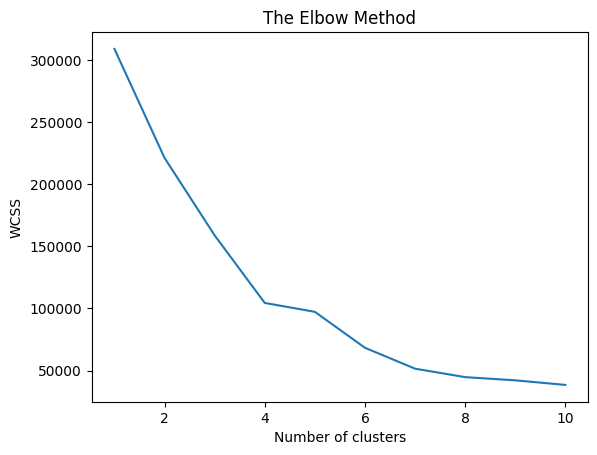

In [12]:
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()#  elbow is from 4-6 i think 7 is over fitting

## Clustering Data Using KMean

In [13]:
kmr = []
for i in np.arange(1,11):
    km = cls.KMeans(n_clusters = 4, init = 'k-means++', random_state = 42)
    y_km = km.fit_predict(df)

In [14]:
kmr = np.append(kmr , met.silhouette_score(df,y_km,))
print(kmr)

[0.40529543]


In [15]:
km.cluster_centers_

array([[ 0.37894737, 44.89473684, 48.70526316, 42.63157895],
       [ 0.46153846, 32.69230769, 86.53846154, 82.12820513],
       [ 0.5       , 24.82142857, 28.71428571, 74.25      ],
       [ 0.52631579, 40.39473684, 87.        , 18.63157895]])

In [16]:
y_km

array([2, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 2,
       0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

## Visualizing The Model

In [17]:
df_np = df.values  # Convert to numpy for the indexing to work

In [18]:
colors = ['red', 'blue', 'green', 'cyan', 'purple', 'pink', 'brown','black','grey','violet','lime','olive','orange']

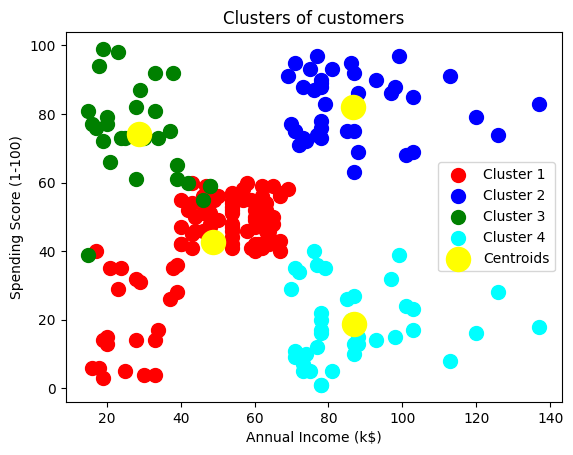

In [19]:
for i in range(4):
    plt.scatter(df_np[y_km == i, 2],
                     df_np[y_km == i, 3],
                     s=100,
                     c=colors[i],
                     label=f'Cluster {i + 1}')
plt.scatter(km.cluster_centers_[:, 2], km.cluster_centers_[:, 3], s=300, c='yellow', label='Centroids')
plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

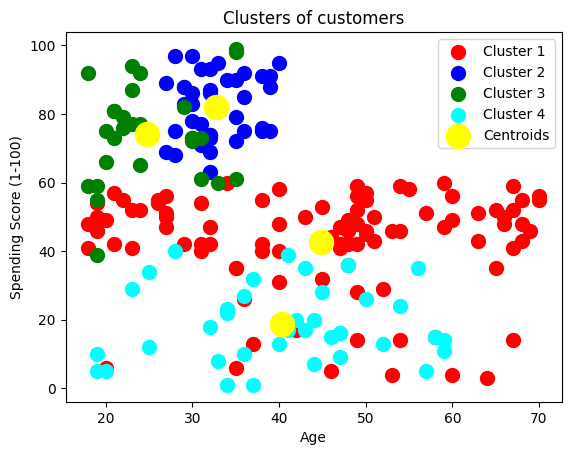

In [20]:
for i in range(4):
    plt.scatter(df_np[y_km == i, 1],
                     df_np[y_km == i, 3],
                     s=100,
                     c=colors[i],
                     label=f'Cluster {i + 1}')
plt.scatter(km.cluster_centers_[:, 1], km.cluster_centers_[:, 3], s=300, c='yellow', label='Centroids')
plt.title('Clusters of customers')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

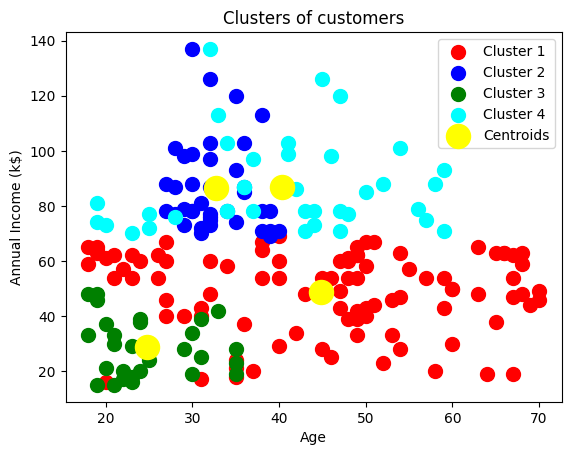

In [21]:
for i in range(4):
    plt.scatter(df_np[y_km == i, 1],
                     df_np[y_km == i, 2],
                     s=100,
                     c=colors[i],
                     label=f'Cluster {i + 1}')

plt.scatter(km.cluster_centers_[:, 1], km.cluster_centers_[:, 2], s=300, c='yellow', label='Centroids')
plt.title('Clusters of customers')
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')
plt.legend()
plt.show()

In [22]:
km = cls.KMeans(n_clusters = 5, init = 'k-means++', random_state = 42)
y_km = km.fit_predict(df)

In [23]:
kmr = np.append(kmr , met.silhouette_score(df,y_km,))
print(kmr)

[0.40529543 0.35740504]


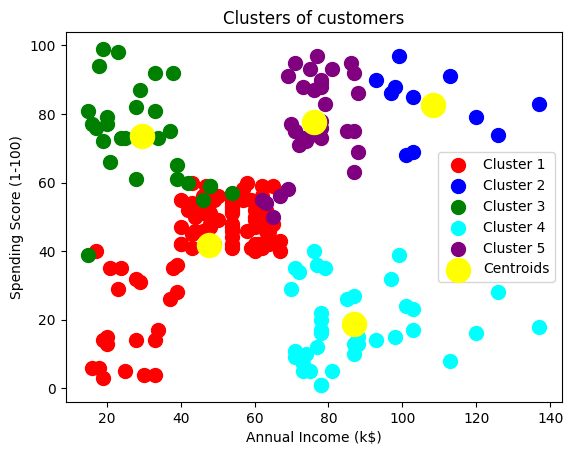

In [24]:
df_np = df.values  # Convert to numpy for the indexing to work
for i in range(5):
    plt.scatter(df_np[y_km == i, 2], df_np[y_km == i, 3], s=100, c=colors[i], label=f'Cluster {i+1}')

plt.scatter(km.cluster_centers_[:, 2], km.cluster_centers_[:, 3], s=300, c='yellow', label='Centroids')
plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

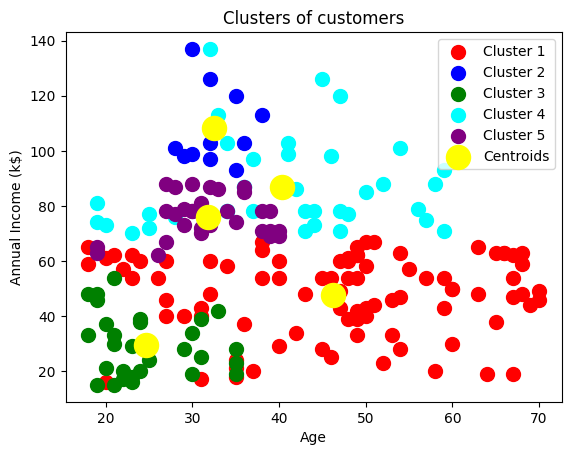

In [25]:
for i in range(5):
    plt.scatter(df_np[y_km == i, 1],
                df_np[y_km == i, 2],
                s=100,
                c=colors[i],
                label=f'Cluster {i + 1}')

plt.scatter(km.cluster_centers_[:, 1], km.cluster_centers_[:, 2], s=300, c='yellow', label='Centroids')
plt.title('Clusters of customers')
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')
plt.legend()
plt.show()

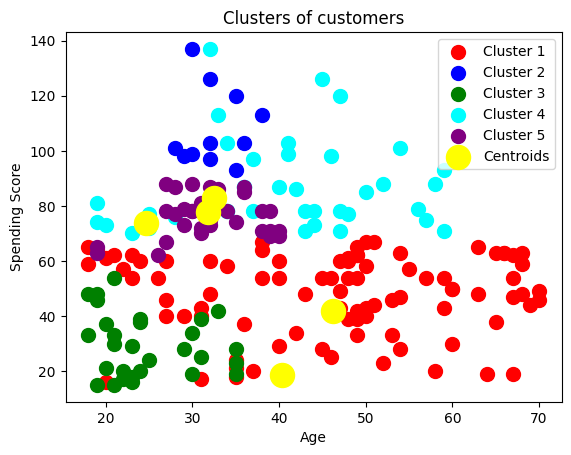

In [26]:
for i in range(5):
    plt.scatter(df_np[y_km == i, 1],
                df_np[y_km == i, 2],
                s=100,
                c=colors[i],
                label=f'Cluster {i + 1}')

plt.scatter(km.cluster_centers_[:, 1], km.cluster_centers_[:, 3], s=300, c='yellow', label='Centroids')
plt.title('Clusters of customers')
plt.xlabel('Age')
plt.ylabel('Spending Score')
plt.legend()
plt.show()

In [27]:
km = cls.KMeans(n_clusters = 6, init = 'k-means++', random_state = 42)
y_km = km.fit_predict(df)

In [28]:
kmr = np.append(kmr , met.silhouette_score(df,y_km,))
print(kmr)

[0.40529543 0.35740504 0.41532496]


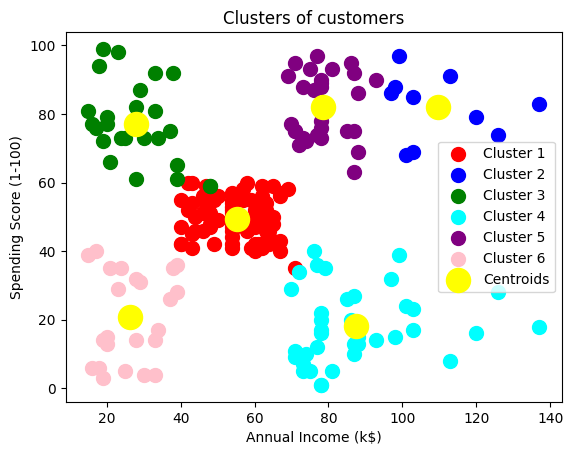

In [29]:
df_np = df.values  # Convert to numpy for the indexing to work
for i in range(6):
    plt.scatter(df_np[y_km == i, 2], df_np[y_km == i, 3], s=100, c=colors[i], label=f'Cluster {i+1}')

plt.scatter(km.cluster_centers_[:, 2], km.cluster_centers_[:, 3], s=300, c='yellow', label='Centroids')
plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

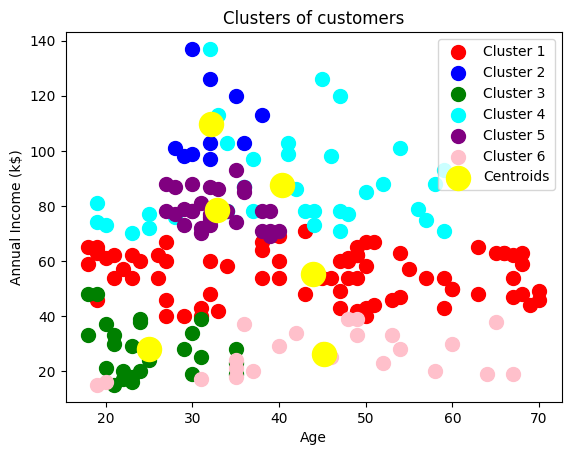

In [30]:
for i in range(6):
    plt.scatter(df_np[y_km == i, 1],
                df_np[y_km == i, 2],
                s=100,
                c=colors[i],
                label=f'Cluster {i + 1}')

plt.scatter(km.cluster_centers_[:, 1], km.cluster_centers_[:, 2], s=300, c='yellow', label='Centroids')
plt.title('Clusters of customers')
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')
plt.legend()
plt.show()

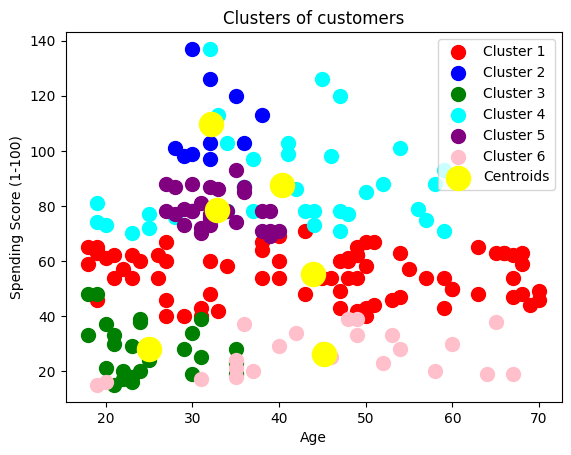

In [31]:
for i in range(6):
    plt.scatter(df_np[y_km == i, 1],
                df_np[y_km == i, 2],
                s=100,
                c=colors[i],
                label=f'Cluster {i + 1}')

plt.scatter(km.cluster_centers_[:, 1], km.cluster_centers_[:, 2], s=300, c='yellow', label='Centroids')
plt.title('Clusters of customers')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

3d Plotting to see if its helpfull

In [32]:
# Split by gender
male = df[df['Gender'] == 1]
female = df[df['Gender'] == 0]

In [33]:

# Cluster on the full data (3 features: Age, Income, Spending)
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].values
km = cls.KMeans(n_clusters=6, init='k-means++', random_state=42)
y_km = km.fit_predict(X)

In [34]:

# Attach cluster labels
df['Cluster'] = y_km
male = df[df['Gender'] == 1]
female = df[df['Gender'] == 0]

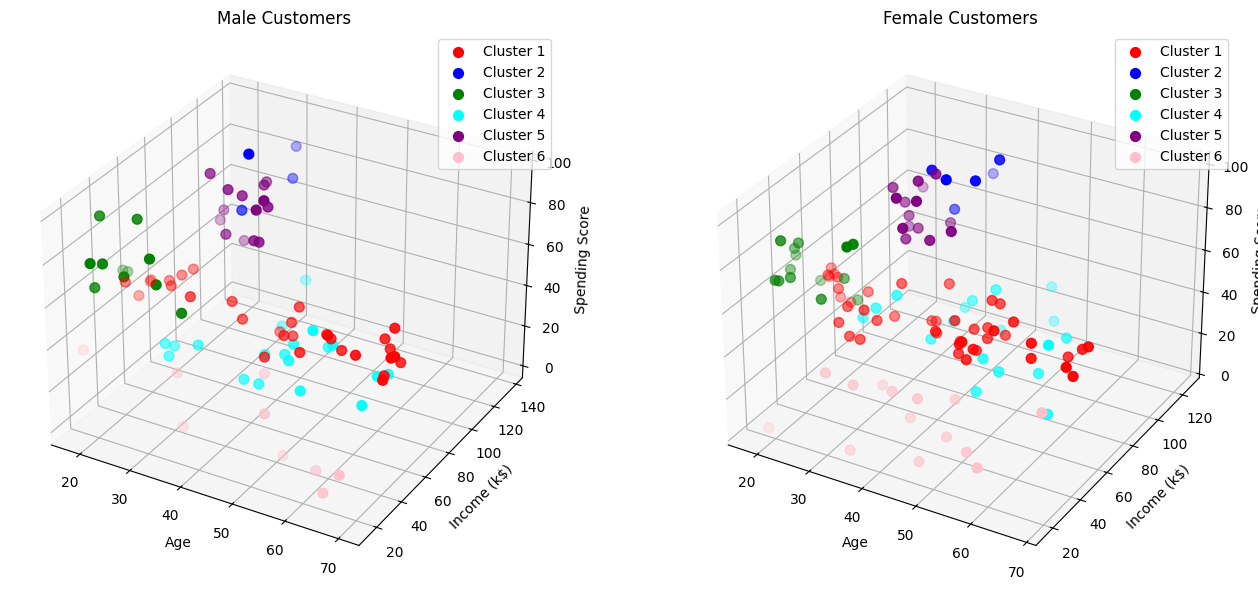

In [35]:

fig = plt.figure(figsize=(14, 6))

# --- Male plot ---
ax1 = fig.add_subplot(121, projection='3d')
for i in range(6):
    cluster_data = male[male['Cluster'] == i]
    ax1.scatter(cluster_data['Age'],
                cluster_data['Annual Income (k$)'],
                cluster_data['Spending Score (1-100)'],
                s=50, c=colors[i], label=f'Cluster {i+1}')
ax1.set_title('Male Customers')
ax1.set_xlabel('Age')
ax1.set_ylabel('Income (k$)')
ax1.set_zlabel('Spending Score')
ax1.legend()

# --- Female plot ---
ax2 = fig.add_subplot(122, projection='3d')
for i in range(6):
    cluster_data = female[female['Cluster'] == i]
    ax2.scatter(cluster_data['Age'],
                cluster_data['Annual Income (k$)'],
                cluster_data['Spending Score (1-100)'],
                s=50, c=colors[i], label=f'Cluster {i+1}')
ax2.set_title('Female Customers')
ax2.set_xlabel('Age')
ax2.set_ylabel('Income (k$)')
ax2.set_zlabel('Spending Score')
ax2.legend()

plt.tight_layout()
plt.show()

3d Plot is not usefull for this data set it seems like random dots that cannot be clusterized

## Re-preprocessing

This Data proves to be Difficult. Im gonna try some new things that might help 1. Capping income 2. Removing Gender 3.See if we should do both or one or non

In [36]:
df1 = df.drop(columns=['Gender'])

In [37]:
kmr_df1 = []
for k in [4,5,6,7]:
    km = cls.KMeans(n_clusters = k, init = 'k-means++', random_state = 42)
    y_km = km.fit_predict(df1)
    score = met.silhouette_score(df1, y_km)
    kmr_df1 = np.append(kmr_df1, score)
    print(f'{k} clusters, silhouette={score:.3f}')
kmr_df1

4 clusters, silhouette=0.405
5 clusters, silhouette=0.368
6 clusters, silhouette=0.418
7 clusters, silhouette=0.443


array([0.40523955, 0.36764743, 0.41839474, 0.44278836])

In [38]:
cap = 95
df_cap = df.copy()
df_cap['Annual Income (k$)'] = df_cap['Annual Income (k$)'].clip(upper = cap)

print(df_cap)

     Gender  Age  Annual Income (k$)  Spending Score (1-100)  Cluster
0         1   19                  15                      39        5
1         1   21                  15                      81        2
2         0   20                  16                       6        5
3         0   23                  16                      77        2
4         0   31                  17                      40        5
..      ...  ...                 ...                     ...      ...
195       0   35                  95                      79        1
196       0   45                  95                      28        3
197       1   32                  95                      74        1
198       1   32                  95                      18        3
199       1   30                  95                      83        1

[200 rows x 5 columns]


In [39]:
kmr_df_cap = []
for k in [4,5,6,7]:
    km = cls.KMeans(n_clusters = k, init = 'k-means++', random_state = 42)
    y_km = km.fit_predict(df_cap)
    score = met.silhouette_score(df_cap, y_km)
    kmr_df_cap = np.append(kmr_df_cap, score)
    print(f'{k} clusters, silhouette={score:.3f}')
kmr_df_cap

4 clusters, silhouette=0.422
5 clusters, silhouette=0.464
6 clusters, silhouette=0.428
7 clusters, silhouette=0.457


array([0.42230707, 0.46435376, 0.42802596, 0.45692522])

In [40]:
df_cap = df_cap.drop(columns=['Gender'])

In [41]:
kmr_df1_cap = []
for k in [4,5,6,7]:
    km = cls.KMeans(n_clusters = k, init = 'k-means++', random_state = 42)
    y_km = km.fit_predict(df_cap)
    score = met.silhouette_score(df_cap, y_km)
    kmr_df1_cap = np.append(kmr_df1_cap, score)
    print(f'{k} clusters, silhouette={score:.3f}')
kmr_df1_cap

4 clusters, silhouette=0.422
5 clusters, silhouette=0.465
6 clusters, silhouette=0.428
7 clusters, silhouette=0.457


array([0.42249393, 0.46459322, 0.42828665, 0.45724779])

In [42]:
print(f'''4Clstr  5Clstr  6Clstr  7Clstr
DF :
{kmr[0]:.3f} , {kmr[1]:.3f} , {kmr[2]:.3f}
DF without Gender :
{kmr_df1 [0]:.3f} , {kmr_df1 [1]:.3f} , {kmr_df1 [2]:.3f} , {kmr_df1 [3]:.3f}
DF with cap income :
{kmr_df_cap [0]:.3f} , {kmr_df_cap [1]:.3f} , {kmr_df_cap [2]:.3f} , {kmr_df_cap [3]:.3f}
DF with no Gender and cap income :
{kmr_df1_cap[0]:.3f} , {kmr_df1_cap[1]:.3f} , {kmr_df1_cap[2]:.3f} , {kmr_df1_cap[3]:.3f}
''')

4Clstr  5Clstr  6Clstr  7Clstr
DF :
0.405 , 0.357 , 0.415
DF without Gender :
0.405 , 0.368 , 0.418 , 0.443
DF with cap income :
0.422 , 0.464 , 0.428 , 0.457
DF with no Gender and cap income :
0.422 , 0.465 , 0.428 , 0.457



Since no gender and cap income helped lets visualize it

In [43]:
km = cls.KMeans(n_clusters = 5, init = 'k-means++', random_state = 42)
y_km = km.fit_predict(df_cap)

In [44]:
df_cap_np = df_cap.values

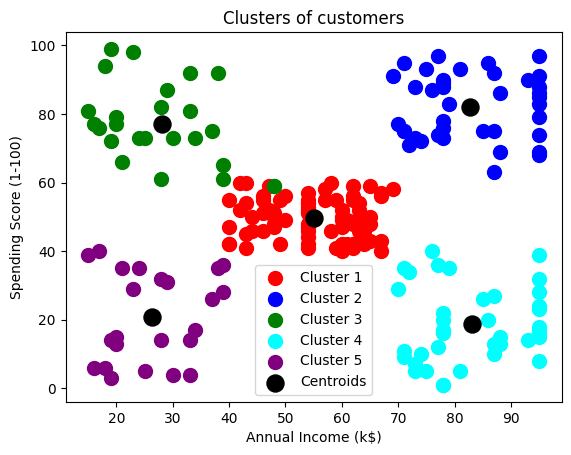

In [45]:
for i in range(5):
    plt.scatter(df_cap_np[y_km == i, 1],
                     df_cap_np[y_km == i, 2],
                     s=100,
                     c=colors[i],
                     label=f'Cluster {i + 1}')

plt.scatter(km.cluster_centers_[:, 1], km.cluster_centers_[:, 2], s=150, c='black', label='Centroids')
plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

## **Well we have good amount of improvment**
by the looks of the graphs this is a far more efficiant clustering than others\
So Based on this we have 5 Group of people\
High income + High Spend = Premium\
High income + Low Spend = Savers\
Avrage income + Avrage Spend = Casuals\
Low income + High Spend = Off people\
Low income + low Spending = Budget Conscious\
So Premiums are the people you dont want to lose maybe even do more for them\
Savers are people who don't waste money the buy what they need so its important that you have what they want\
Casuals are easy going people but they have limits they are the biggest cluster\
Off People are the people who are looking for discounts meaning they dont have much money but they are into buying\
Budget Conscious are the people who spend as less money as possible because they have kids to send to collage and rent and a family to feed

## DBSCAN

In [46]:
for eps_val in [3,5,7,9,11,12,13,14,15,16,17,18,19,20]:
    for ms in [3,4,5,6,7] :
        db = cls.DBSCAN(eps=eps_val, min_samples=ms).fit(df_cap)
        labels = db.labels_
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        if n_clusters >=2:
            score = met.silhouette_score(df_cap, labels)
            if score >= 0.3:
                print(f'eps={eps_val}, Minimum Samples = {ms}: {n_clusters} clusters, {n_noise} noise, silhouette={score:.3f}')

eps=12, Minimum Samples = 6: 3 clusters, 40 noise, silhouette=0.330
eps=12, Minimum Samples = 7: 4 clusters, 46 noise, silhouette=0.324
eps=13, Minimum Samples = 6: 4 clusters, 19 noise, silhouette=0.326
eps=14, Minimum Samples = 6: 4 clusters, 12 noise, silhouette=0.343
eps=14, Minimum Samples = 7: 4 clusters, 15 noise, silhouette=0.329
eps=15, Minimum Samples = 7: 4 clusters, 7 noise, silhouette=0.350
eps=16, Minimum Samples = 3: 2 clusters, 0 noise, silhouette=0.320
eps=16, Minimum Samples = 4: 2 clusters, 0 noise, silhouette=0.320
eps=16, Minimum Samples = 7: 3 clusters, 3 noise, silhouette=0.305


DBSCAN doesn't win over KMeans Lets see if we scale what happens\
I scaled the data and KMeans was not happy with the scaled data so i trained KMeans with raw data(yes it was intentional)

In [47]:
db = cls.DBSCAN(eps=15, min_samples=7).fit(df_cap)
label = db.labels_

In [48]:
set(label)

{np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3)}

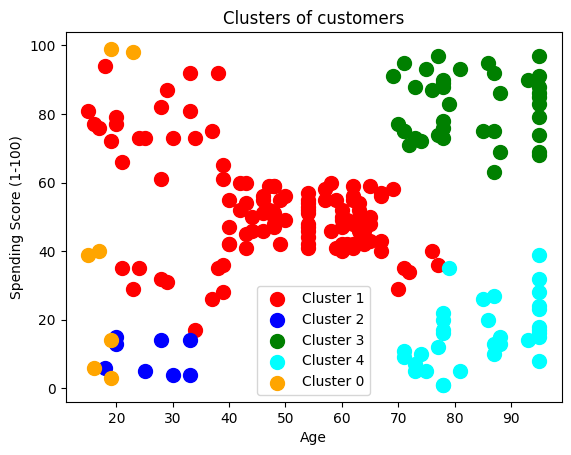

In [49]:
df_cap_np = df_cap.values
for i in set(label):
    plt.scatter(df_cap_np[label == i, 1],
                df_cap_np[label == i, 2],
                s=100,
                c=colors[i],
                label=f'Cluster {i + 1}')
    i = i + 1
plt.title('Clusters of customers')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

In [50]:
sc = pp.StandardScaler()
df_cap = sc.fit_transform(df_cap)

In [57]:
for eps_val in [0.5, 0.7, 0.9, 1.1, 1.3, 1.5, 1.7, 2.0]:
    for ms in [3,4,5,6,7] :
        db = cls.DBSCAN(eps=eps_val, min_samples=ms).fit(df_cap)
        labels = db.labels_
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        if n_clusters >=2:
            score = met.silhouette_score(df_cap, labels)
            if score >= 0.4:
                print(f'eps={eps_val}, Minimum Samples = {ms}: {n_clusters} clusters, {n_noise} noise, silhouette={score:.3f}')

eps=0.7, Minimum Samples = 3: 8 clusters, 7 noise, silhouette=0.411
eps=0.7, Minimum Samples = 4: 7 clusters, 11 noise, silhouette=0.420
eps=0.7, Minimum Samples = 5: 6 clusters, 15 noise, silhouette=0.437
eps=0.7, Minimum Samples = 6: 6 clusters, 19 noise, silhouette=0.417
eps=0.9, Minimum Samples = 3: 6 clusters, 2 noise, silhouette=0.460
eps=0.9, Minimum Samples = 4: 6 clusters, 2 noise, silhouette=0.460
eps=0.9, Minimum Samples = 5: 6 clusters, 2 noise, silhouette=0.460
eps=0.9, Minimum Samples = 6: 6 clusters, 3 noise, silhouette=0.465
eps=0.9, Minimum Samples = 7: 6 clusters, 3 noise, silhouette=0.465
eps=1.1, Minimum Samples = 3: 6 clusters, 1 noise, silhouette=0.442
eps=1.1, Minimum Samples = 4: 6 clusters, 1 noise, silhouette=0.442
eps=1.1, Minimum Samples = 5: 6 clusters, 1 noise, silhouette=0.442
eps=1.1, Minimum Samples = 6: 6 clusters, 2 noise, silhouette=0.460
eps=1.1, Minimum Samples = 7: 6 clusters, 3 noise, silhouette=0.465


In [98]:
db = cls.DBSCAN(eps = 1.1 , min_samples= 7 ).fit(df_cap)
label = db.labels_
met.silhouette_score(df_cap, label )

0.4647765285129675

In [99]:
set(label)

{np.int64(-1),
 np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5)}

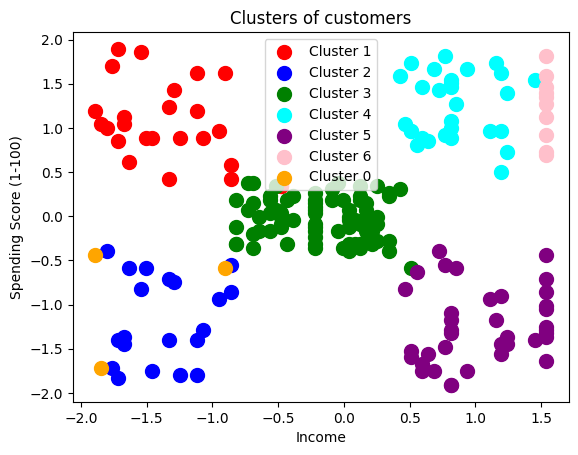

In [100]:
for i in  set(label) :
    plt.scatter(df_cap[label == i, 1],
                df_cap[label == i, 2],
                s=100,
                c=colors[i],
                label=f'Cluster {i + 1}')
    i = i + 1

plt.title('Clusters of customers')
plt.xlabel('Income')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()#also same shit

I modeled all the 0.465 score and they have the same clustering like the one on the top cell\
I do not think that this needs more analyze but there is somthing that i should add is a last cluster which happend with DBSCAN so lets talk about it\
that cluster should be called Too OLD Rich
the only thing that you cant see in this graph is the age factor so this the only diffrence that can seprate that cluster from the ones right next to them\
These Too OLD Rich people they dont care for the money because they have and they are not afraid to spend so you should have somthing else that keep them in your supermarket stuff like respecting elderly ir taking their bags to their cars and on and on\

**Conclusion**

After testing K-Means (k=4-7) and DBSCAN across multiple feature sets:
- **Best model:** K-Means, k=5, on capped income ($95k max) without Gender
- **Silhouette score:** 0.465 (12% improvement over baseline)
- **Key finding:** Income capping removed outlier distortion; Gender added noise, not signal
- **Business application:** 5 actionable customer segments for targeted marketing

DBSCAN on scaled data matched K-Means performance (0.465) but identified an additional
age-separated high-wealth cluster that K-Means missed, suggesting hybrid approaches for production.